# NFL Draft Model
## Draft Class Deep Dive

This notebook takes a deeper look at specific draft classes and position groups — identifying the best and worst picks by round, the most valuable late round steals, and building a comprehensive view of draft value across positions and eras.

---

### Setup & Data Load

In [1]:
%pip install matplotlib seaborn pandas==2.2.2 --prefer-binary


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


---

### Imports & Data Load

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
processed_path = os.path.join(project_root, "data", "processed")
figures_path = os.path.join(project_root, "outputs", "figures")

df = pd.read_parquet(os.path.join(processed_path, "predictions.parquet"), engine='pyarrow')
draft_original = pd.read_parquet(os.path.join(processed_path, "draft_picks_clean.parquet"), 
                                  engine='pyarrow')

# Merge team info
df = df.merge(draft_original[['pfr_player_id', 'team', 'probowls', 'allpro', 'hof']], 
              on='pfr_player_id', how='left')

print(f"Dataset shape: {df.shape}")
print(f"\nSeason range: {df['season_draft'].min()} - {df['season_draft'].max()}")
print(f"Total players: {len(df):,}")

Dataset shape: (2779, 44)

Season range: 2010 - 2021
Total players: 2,779


Dataset loaded with 44 columns including pro bowl selections, all-pro honors, and HOF status merged from the original draft data.

---

### Best Picks by Round
Which players generated the most value relative to their draft position?

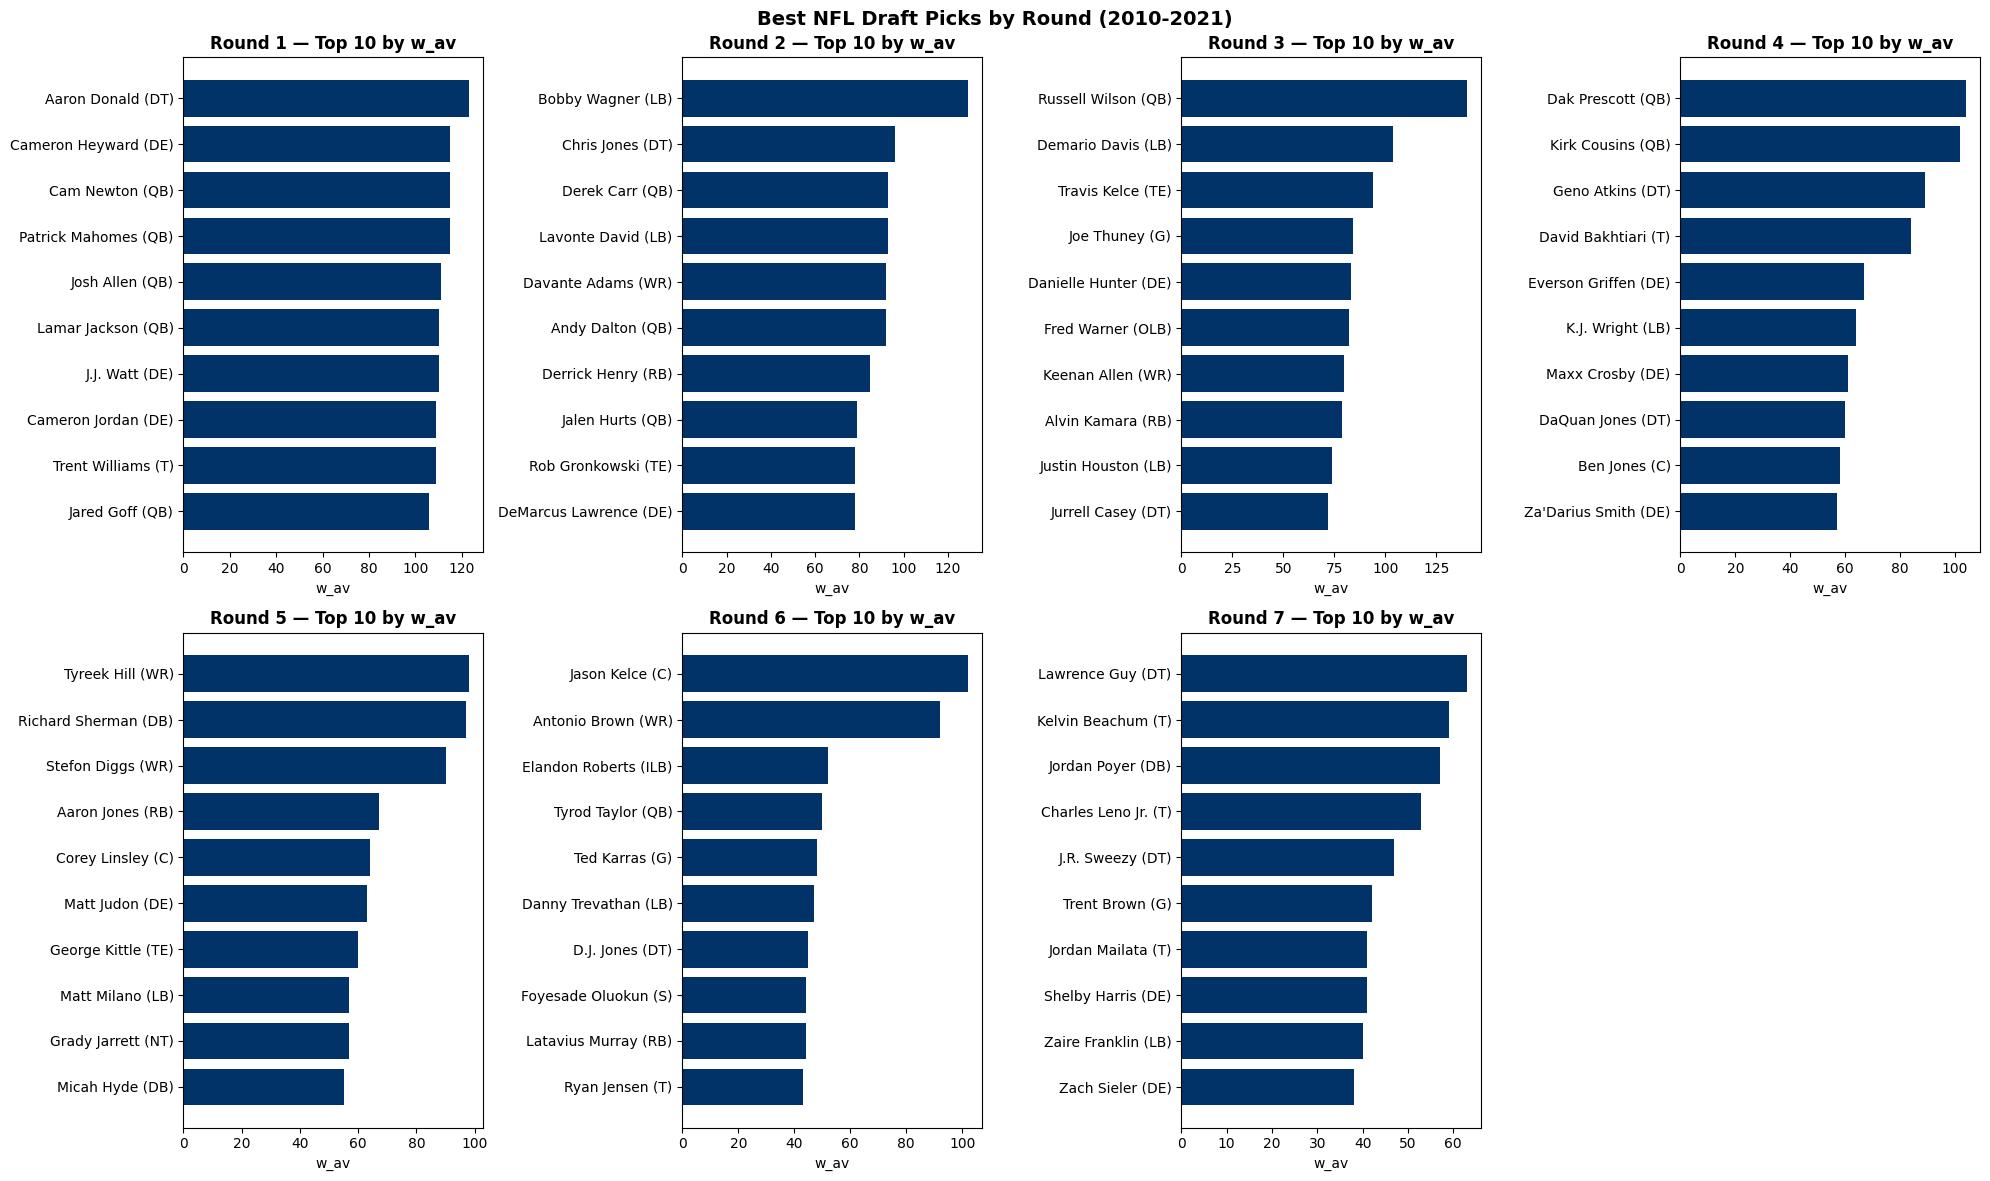

In [3]:
# Best picks by round - highest w_av relative to pick number
df['pick_value'] = df['w_av'] - df['pred_wav']

fig, axes = plt.subplots(2, 4, figsize=(20, 12))
axes = axes.flatten()

for idx, rd in enumerate(range(1, 8)):
    round_df = df[df['round'] == rd].sort_values('w_av', ascending=False).head(10)
    
    colors = ['#013369'] * len(round_df)
    axes[idx].barh(
        round_df['pfr_player_name'] + ' (' + round_df['position_draft'] + ')',
        round_df['w_av'],
        color=colors
    )
    axes[idx].set_title(f'Round {rd} — Top 10 by w_av', fontweight='bold')
    axes[idx].set_xlabel('w_av')
    axes[idx].invert_yaxis()

# Hide last subplot
axes[7].set_visible(False)

plt.suptitle('Best NFL Draft Picks by Round (2010-2021)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(figures_path, "best_picks_by_round.png"), dpi=150, bbox_inches='tight')
plt.show()

![Best Picks by Round](../outputs/figures/best_picks_by_round.png)

This chart is a who's who of NFL talent from 2010-2021 and validates the dataset is correctly capturing player value:

**Round 1 legends:** Aaron Donald, Patrick Mahomes, Josh Allen, Lamar Jackson, J.J. Watt — all generational talents at the top

**Round 2 steals:** Bobby Wagner, Chris Jones, Davante Adams, Derrick Henry, Jalen Hurts — exceptional value picks that outperformed their slot

**Round 3 gems:** Russell Wilson, Travis Kelce, Danielle Hunter, Fred Warner, Keenan Allen, Alvin Kamara — one of the greatest collections of round 3 value in NFL history

**Round 4 surprises:** Dak Prescott, Kirk Cousins, Maxx Crosby, David Bakhtiari — quarterbacks and pass rushers finding elite careers in round 4

**Round 5-7 steals:** Jason Kelce (6th round), Antonio Brown (6th round), Tyreek Hill (5th round), Richard Sherman (5th round) — the late round finds that define great drafting organizations

---

### Greatest Late Round Steals
Who provided the most value relative to when they were drafted?

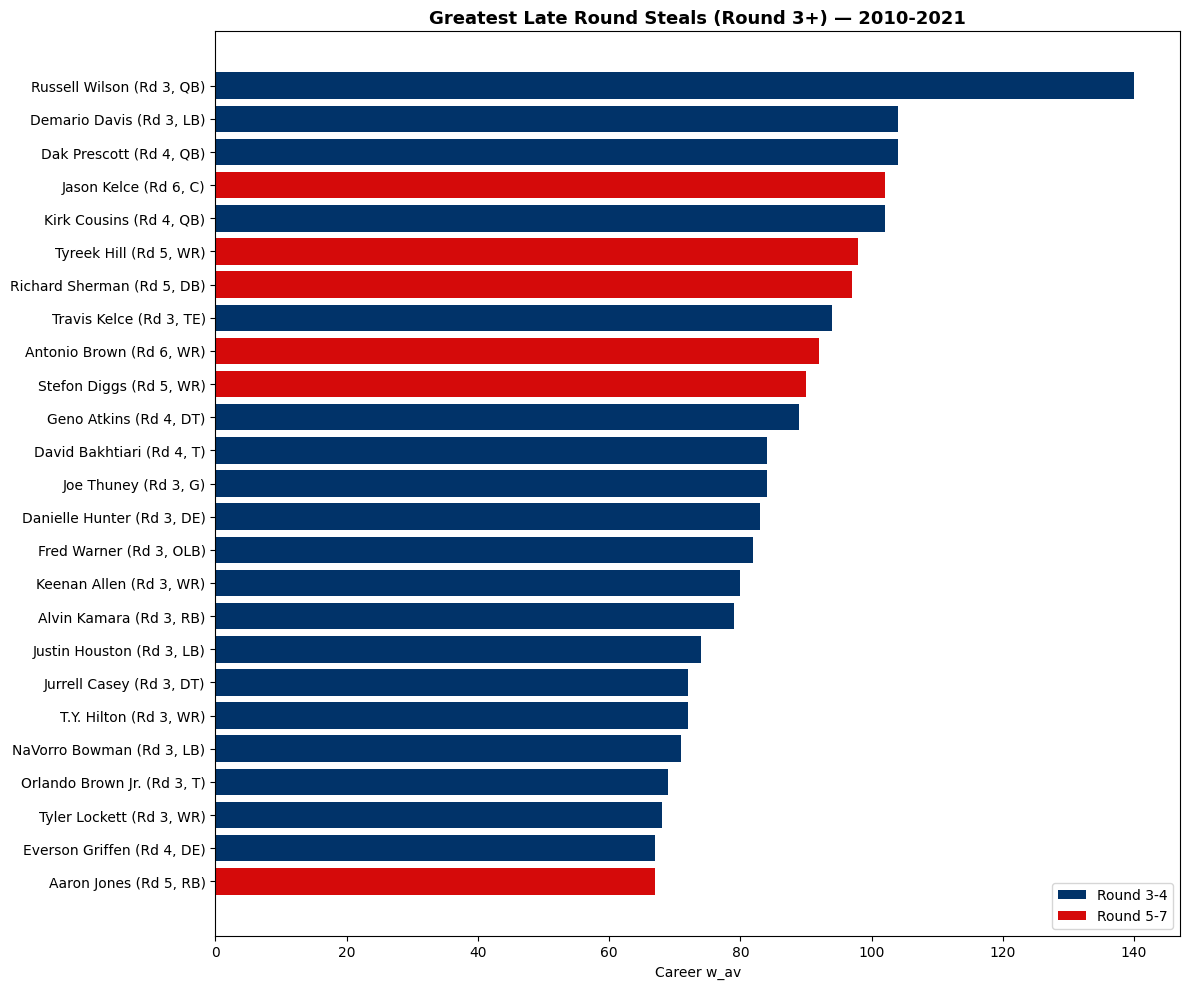

  pfr_player_name position_draft  season_draft  round  pick team  w_av
   Russell Wilson             QB          2012      3    75  SEA 140.0
    Demario Davis             LB          2012      3    77  NYJ 104.0
     Dak Prescott             QB          2016      4   135  DAL 104.0
      Jason Kelce              C          2011      6   191  PHI 102.0
     Kirk Cousins             QB          2012      4   102  WAS 102.0
      Tyreek Hill             WR          2016      5   165  KAN  98.0
  Richard Sherman             DB          2011      5   154  SEA  97.0
     Travis Kelce             TE          2013      3    63  KAN  94.0
    Antonio Brown             WR          2010      6   195  PIT  92.0
     Stefon Diggs             WR          2015      5   146  MIN  90.0
      Geno Atkins             DT          2010      4   120  CIN  89.0
  David Bakhtiari              T          2013      4   109  GNB  84.0
       Joe Thuney              G          2016      3    78  NWE  84.0
  Dani

In [4]:
# Greatest late round steals - high w_av from rounds 3-7
late_round_steals = df[df['round'] >= 3].sort_values('w_av', ascending=False).head(25)

plt.figure(figsize=(12, 10))
colors = ['#013369' if r <= 4 else '#D50A0A' for r in late_round_steals['round']]
bars = plt.barh(
    late_round_steals['pfr_player_name'] + ' (Rd ' + late_round_steals['round'].astype(str) + ', ' + late_round_steals['position_draft'] + ')',
    late_round_steals['w_av'],
    color=colors
)
plt.title('Greatest Late Round Steals (Round 3+) — 2010-2021', fontsize=13, fontweight='bold')
plt.xlabel('Career w_av')
plt.gca().invert_yaxis()

# Add legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#013369', label='Round 3-4'),
                   Patch(facecolor='#D50A0A', label='Round 5-7')]
plt.legend(handles=legend_elements)
plt.tight_layout()
plt.savefig(os.path.join(figures_path, "late_round_steals.png"), dpi=150, bbox_inches='tight')
plt.show()

print(late_round_steals[['pfr_player_name', 'position_draft', 'season_draft', 
                          'round', 'pick', 'team', 'w_av']].to_string(index=False))

![Late Round Steals](../outputs/figures/late_round_steals.png)

This is one of the most compelling charts in the project — a who's who of players who defied their draft position:

**The greatest steal in the dataset: Russell Wilson (Round 3, Pick 75, 140 w_av)** — the most valuable player drafted after Round 2 in the entire 2010-2021 period. Seattle passed on him twice before finally selecting him, and he became one of the greatest QBs of his generation.

**Round 6-7 legends:**
- **Jason Kelce (Round 6, Pick 191)** — 102 w_av, arguably the greatest center in NFL history found in the 6th round
- **Antonio Brown (Round 6, Pick 195)** — 92 w_av before off-field issues, one of the greatest WRs ever found in the 6th round
- **Tyreek Hill (Round 5)** and **Richard Sherman (Round 5)** — both All-Pro players found in the 5th round

**The QB pattern:** Russell Wilson (Rd 3), Dak Prescott (Rd 4), Kirk Cousins (Rd 4) — three franchise QBs found outside the first two rounds in just the 2011-2016 window. This directly validates the finding that QB is the most unpredictable position to evaluate.

---

### Position Value by Draft Round
How does the expected value of each position change across rounds?

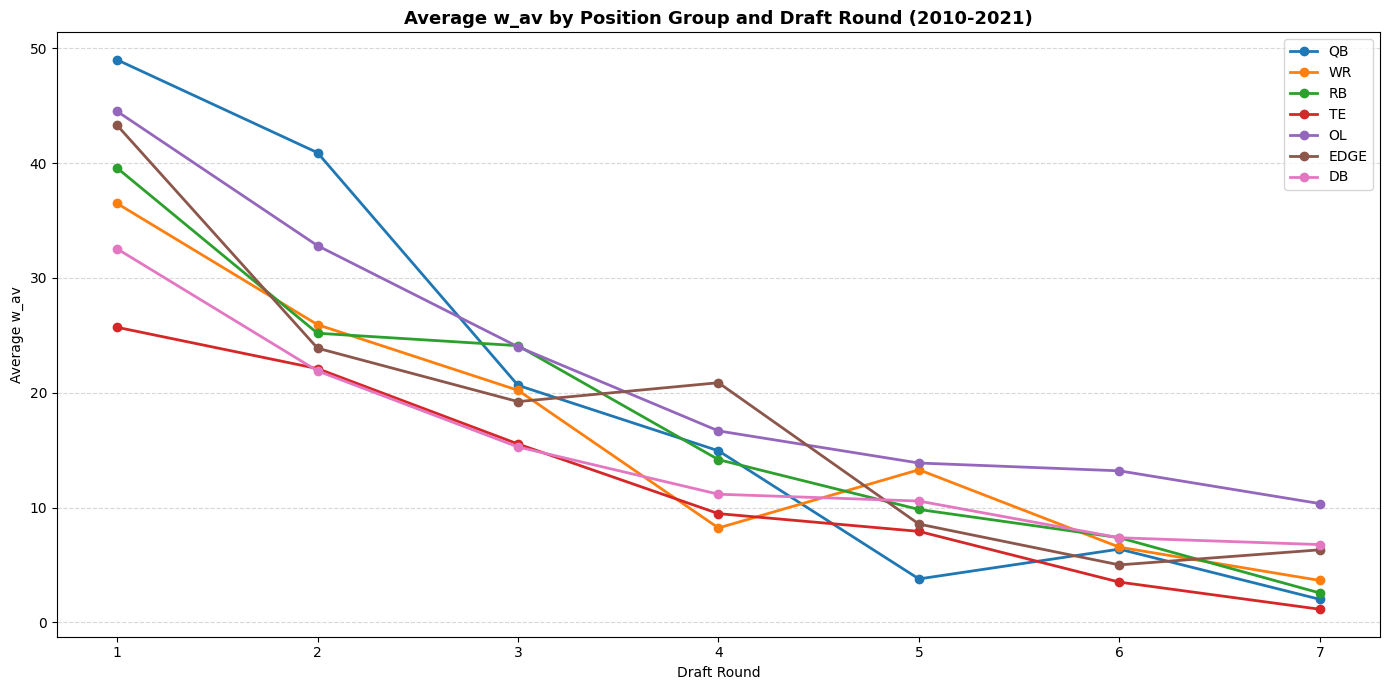

In [5]:
# Average w_av by position and round
position_round = df.groupby(['position_group', 'round'])['w_av'].mean().reset_index()
position_round = position_round[position_round['position_group'].isin(
    ['QB', 'RB', 'WR', 'TE', 'OL', 'EDGE', 'DT', 'LB', 'DB']
)]

plt.figure(figsize=(14, 7))
for pos in ['QB', 'WR', 'RB', 'TE', 'OL', 'EDGE', 'DB']:
    data = position_round[position_round['position_group'] == pos]
    plt.plot(data['round'], data['w_av'], marker='o', linewidth=2, label=pos)

plt.title('Average w_av by Position Group and Draft Round (2010-2021)', 
          fontsize=13, fontweight='bold')
plt.xlabel('Draft Round')
plt.ylabel('Average w_av')
plt.xticks(range(1, 8))
plt.legend(loc='upper right')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig(os.path.join(figures_path, "position_value_by_round.png"), dpi=150, bbox_inches='tight')
plt.show()

![Position Value by Round](../outputs/figures/position_value_by_round.png)

The position value by round chart reveals how quickly each position's expected value declines across rounds:

**QB (blue) — the steepest decline:**
- Round 1 QBs average 49 w_av — the highest of any position in Round 1
- Drops sharply to 41 in Round 2, then collapses to 4 by Round 5
- The extreme variance confirms QB is the highest risk/highest reward position — elite Round 1 QBs are the most valuable players in football, but late round QBs almost never pan out

**OL (purple) — the most durable value:**
- Maintains the highest w_av from Round 2 through Round 7
- Still averaging 10+ w_av in Round 7 — the best late round value of any position
- Linemen have long careers and accumulate value steadily, making them excellent late round picks

**EDGE (brown) — late round spike:**
- Notable uptick in Round 4 (21 w_av) — the data confirms that pass rushers can be found later than most positions
- Players like Danielle Hunter and Maxx Crosby validate this finding

**RB (green) — rapid decline:**
- Strong in Round 1 (39 w_av) but falls quickly
- Very little value expected after Round 3 — confirms the league-wide devaluation of the running back position

**DB (pink) — consistently moderate:**
- Relatively flat decline across rounds compared to skill positions
- Maintains decent value through Round 5, confirming DBs are findable throughout the draft

---

### Summary
This notebook completes the draft analysis with the most compelling player-level findings:

1. **Russell Wilson is the greatest late round steal** — 140 w_av from Round 3, Pick 75
2. **Jason Kelce (Round 6) and Antonio Brown (Round 6)** — proof that all-time greats can be found anywhere in the draft
3. **OL provides the best late round value** — maintains meaningful w_av through Round 7 better than any other position
4. **QB has the steepest value decline** — elite in Round 1, nearly worthless by Round 5
5. **Three franchise QBs (Wilson, Prescott, Cousins) found in Rounds 3-4** in just a 5-year window — confirming QB evaluation is the hardest problem in football